In [1]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# --- 1. Load Your Original Data ---
try:
    df_raw = pd.read_csv('Air Traffic Data Final.csv')
    print("Successfully loaded 'Air Traffic Data Final.csv'")
except FileNotFoundError:
    print("Error: The file 'Air Traffic Data Final.csv' was not found.")
    print("Please make sure it's in the same directory as this script.")
    exit()

# --- 2. Pre-process Data ---
# Assuming the date column is the first one, 'Date'
date_column_name = df_raw.columns[0]

try:
    df_raw[date_column_name] = pd.to_datetime(df_raw[date_column_name])
    df_raw.set_index(date_column_name, inplace=True)
    df_raw.sort_index(inplace=True)
except Exception as e:
    print(f"Error processing date column: {e}")
    exit()

# Define the new, clean names in the exact order of the original file
new_column_names = [
    'dom_pass',
    'int_pass',
    'dom_freight',
    'int_freight',
    'gdp',
    'population',
    'jet_fuel',
    'inflation',
    'unemployment',
    'exchange_rate'
]

# Rename the columns
try:
    df_raw.columns = new_column_names
    print("Columns successfully renamed.")
except ValueError as e:
    print(f"Error renaming columns: {e}")
    exit()

# Convert all data to float64 to prevent errors
df_raw = df_raw.astype('float64')

# --- 3. Save the Cleaned Historical Data ---
df_raw.to_csv('preprocessed_historical_data.csv')
print("Saved 'preprocessed_historical_data.csv'.")


# --- 4. Generate Realistic Future Exogenous Data (10 steps) ---
print("Generating 10-step future exogenous data...")

exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']

# Get the last date and frequency
last_date = df_raw.index[-1]
# Infer frequency, default to 'MS' (Month Start) if not found
freq = pd.infer_freq(df_raw.index)
if freq is None:
    print("Could not infer frequency, assuming 'MS' (Month Start).")
    freq = 'MS'
else:
    print(f"Inferred frequency: {freq}")

future_dates = pd.date_range(start=last_date, periods=11, freq=freq)[1:]
df_future_exog = pd.DataFrame(index=future_dates)

# Generate forecasts using a "Random Walk with Drift"
for col in exog_cols:
    # Calculate historical drift (mean change) and volatility (std dev of change)
    diffs = df_raw[col].diff().dropna()
    diff_mean = diffs.mean()
    diff_std = diffs.std()
    
    # Get the last known value
    last_value = df_raw[col].iloc[-1]
    
    # Generate 10 random "shocks" from this distribution
    shocks = np.random.normal(loc=diff_mean, scale=diff_std, size=10)
    
    # Create the forecast by cumulatively adding the shocks to the last value
    forecast = last_value + np.cumsum(shocks)
    
    df_future_exog[col] = forecast

print("\n--- Generated 'df_future_exog' ---")
print(df_future_exog)

# --- 5. Save the Future Exogenous Data ---
df_future_exog.to_csv('future_exog_data.csv')
print("Saved 'future_exog_data.csv'.")

print("\n✅ All necessary files have been generated!")

Successfully loaded 'Air Traffic Data Final.csv'
Columns successfully renamed.
Saved 'preprocessed_historical_data.csv'.
Generating 10-step future exogenous data...
Could not infer frequency, assuming 'MS' (Month Start).

--- Generated 'df_future_exog' ---
                     gdp    population    jet_fuel  inflation  unemployment  \
2024-03-01  3.958142e+12  1.440992e+09  199.519445   4.632230      4.334522   
2024-04-01  3.962693e+12  1.440255e+09  196.836846   5.483823      4.351828   
2024-05-01  4.017884e+12  1.442358e+09  198.361449   5.446344      4.309809   
2024-06-01  4.129475e+12  1.435812e+09  178.480625   4.911281      4.229457   
2024-07-01  4.127848e+12  1.430022e+09  171.227889   5.272190      3.905739   
2024-08-01  4.126221e+12  1.428897e+09  173.374947   4.659391      3.738836   
2024-09-01  4.241432e+12  1.425965e+09  157.420899   4.727871      3.625509   
2024-10-01  4.304338e+12  1.428358e+09  163.365934   3.763010      3.825895   
2024-11-01  4.287549e+12  1.4258

Successfully loaded historical and future data.
Decomposing 'dom_pass' series...
Saved decomposition_plot.png
Forecasting Trend component...
Forecasting Seasonal component...
Training XGBoost model on Residuals...
Forecasting Residuals component...


ValueError: Incompatible indexer with Series

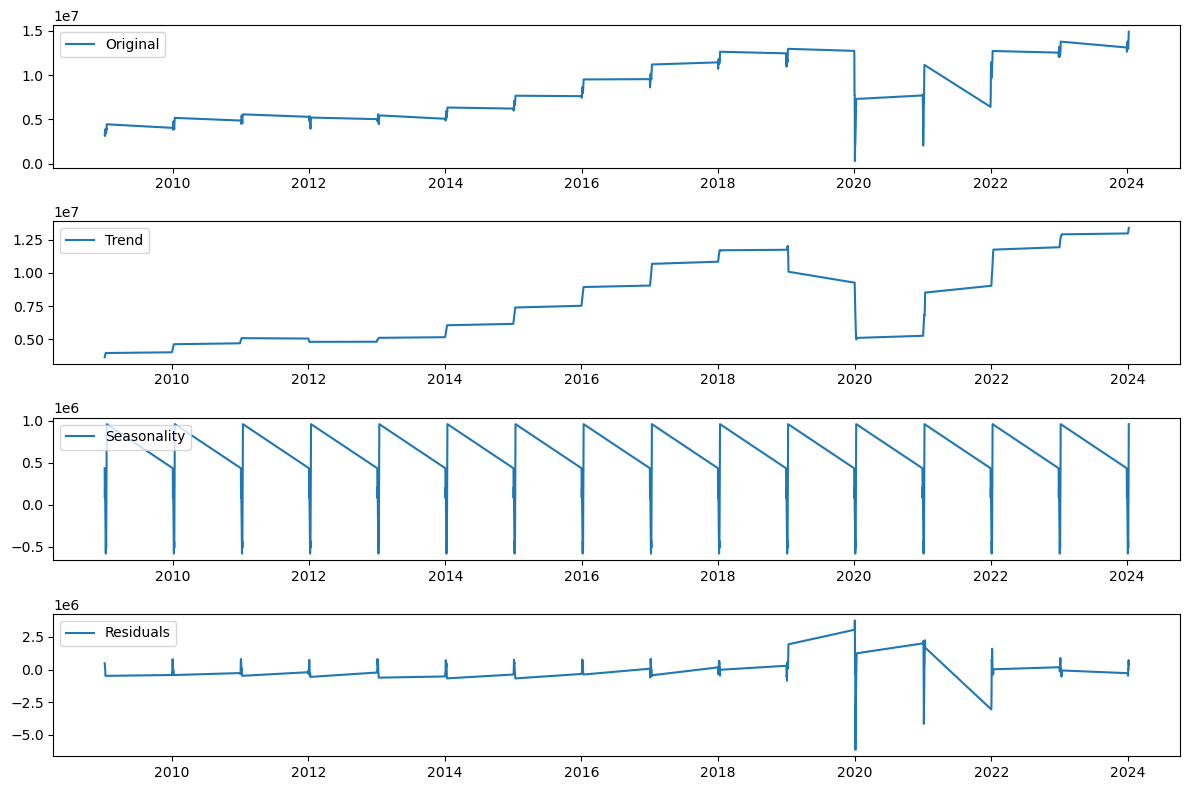

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings('ignore')

# --- 1. Load Data (This will now work) ---
try:
    df_raw = pd.read_csv('preprocessed_historical_data.csv', index_col=0, parse_dates=True)
    df_future_exog = pd.read_csv('future_exog_data.csv', index_col=0, parse_dates=True)
    print("Successfully loaded historical and future data.")
except FileNotFoundError:
    print("Error: Could not find data files.")
    exit()

# Define Columns
target_cols = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight']
exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']

# --- 2. Decompose the 'dom_pass' Time Series ---
print("Decomposing 'dom_pass' series...")
# We need at least 2 full cycles (24 months) for decomposition
decomposition = seasonal_decompose(df_raw['dom_pass'], model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Add these new components to our main DataFrame
df_raw['dom_pass_trend'] = trend
df_raw['dom_pass_seasonal'] = seasonal
df_raw['dom_pass_resid'] = residual

# Plot the decomposition
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(df_raw['dom_pass'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(df_raw['dom_pass_trend'], label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(df_raw['dom_pass_seasonal'], label='Seasonality')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(df_raw['dom_pass_resid'], label='Residuals')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('decomposition_plot.png') # Save the plot
print("Saved decomposition_plot.png")


# --- 3. Feature Engineering for RESIDUALS ---
def create_residual_features(df):
    """
    This function creates features to predict the RESIDUALS.
    """
    df_with_features = df.copy()
    
    # --- Outlier Detection ---
    rolling_mean = df_with_features['dom_pass'].shift(1).rolling(window=12).mean()
    rolling_std = df_with_features['dom_pass'].shift(1).rolling(window=12).std()
    threshold = rolling_mean - (3 * rolling_std)
    df_with_features['is_outlier'] = (df_with_features['dom_pass'] < threshold).astype(int)
    
    n_lags = 6 # Using the 6-lag set that worked best
    
    # Define all columns that will be used to create features
    cols_to_lag = target_cols + exog_cols + ['is_outlier', 'dom_pass_trend', 'dom_pass_seasonal']
    
    for col in cols_to_lag:
        if col in df_with_features.columns:
            for i in range(1, n_lags + 1):
                df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
            
    # Time features
    df_with_features['month'] = df_with_features.index.month
    df_with_features['quarter'] = df_with_features.index.quarter
    
    # Also add lags of the target-to-be-predicted (the residual)
    for i in range(1, n_lags + 1):
        df_with_features[f'dom_pass_resid_lag_{i}'] = df_with_features['dom_pass_resid'].shift(i)
        
    df_with_features = df_with_features.dropna()
    return df_with_features

# --- 4. Recursive Function to Forecast RESIDUALS ---
def forecast_residuals_recursive(model, scaler_X, scaler_y, 
                                 df_history, df_future_exog, 
                                 forecasted_trend, forecasted_seasonal, 
                                 n_steps=10):
    
    history_copy = df_history.copy()
    predictions = []

    for i in range(n_steps):
        future_date = df_future_exog.index[i]
        future_exog_row = df_future_exog.iloc[[i]].copy()
        
        # Add the 'known' future trend and seasonal parts
        future_exog_row['dom_pass_trend'] = forecasted_trend.iloc[i]
        future_exog_row['dom_pass_seasonal'] = forecasted_seasonal.iloc[i]

        temp_df = pd.concat([history_copy, future_exog_row])
        
        # Create features
        df_features_full = create_residual_features(temp_df)
        
        # Get the feature names the model was trained on
        feature_names = scaler_X.get_feature_names_out()
        
        # Ensure all feature names are present in the dataframe
        # This handles missing columns (e.g., 'is_outlier' in future)
        X_to_predict_df = pd.DataFrame(columns=feature_names, index=[future_date])
        
        # Get the last row of features
        last_feature_row = df_features_full.iloc[[-1]]
        
        # Fill the X_to_predict_df with available data
        for col in feature_names:
            if col in last_feature_row.columns:
                X_to_predict_df[col] = last_feature_row[col].values
        
        # Handle any potential NaNs (e.g., if a lag can't be computed)
        X_to_predict_df = X_to_predict_df.fillna(0) 

        # Scale and Predict
        X_to_predict_scaled = scaler_X.transform(X_to_predict_df)
        y_pred_scaled = model.predict(X_to_predict_scaled)
        y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]
        
        predictions.append(y_pred_original)
        
        # Update history for the next loop
        history_copy.loc[future_date, 'dom_pass_resid'] = y_pred_original
        for col in df_future_exog.columns:
            history_copy.loc[future_date, col] = future_exog_row[col].values[0]
        history_copy.loc[future_date, 'dom_pass_trend'] = forecasted_trend.iloc[i]
        history_copy.loc[future_date, 'dom_pass_seasonal'] = forecasted_seasonal.iloc[i]
        history_copy.loc[future_date, 'dom_pass'] = forecasted_trend.iloc[i] + forecasted_seasonal.iloc[i] + y_pred_original


    return pd.Series(predictions, index=df_future_exog.index)

# --- 5. Main Execution ---

# 5a. === Forecast Trend ===
print("Forecasting Trend component...")
trend_df = df_raw[['dom_pass_trend']].dropna()
trend_slope = (trend_df.iloc[-1] - trend_df.iloc[-12]) / 12
last_trend_value = trend_df.iloc[-1].values[0]

future_trend_values = []
for i in range(1, 11):
    future_trend_values.append(last_trend_value + (i * trend_slope))
forecasted_trend = pd.Series(future_trend_values, index=df_future_exog.index)

# 5b. === Forecast Seasonality ===
print("Forecasting Seasonal component...")
last_12_season = df_raw['dom_pass_seasonal'].iloc[-12:]
future_seasonal_values = []
for i in range(10):
    future_seasonal_values.append(last_12_season.iloc[i])
forecasted_seasonal = pd.Series(future_seasonal_values, index=df_future_exog.index)

# 5c. === Train Model and Forecast Residuals ===
print("Training XGBoost model on Residuals...")
df_resid_features = create_residual_features(df_raw)

# Our new target is 'dom_pass_resid'
X_full = df_resid_features.drop(columns=[col for col in target_cols + ['dom_pass_trend', 'dom_pass_seasonal', 'dom_pass_resid'] if col in df_resid_features.columns])
y_full = df_resid_features['dom_pass_resid']

# Fit scalers
scaler_X_resid = StandardScaler().fit(X_full)
X_full_scaled = scaler_X_resid.transform(X_full)

scaler_y_resid = StandardScaler().fit(y_full.to_frame())
y_full_scaled = scaler_y_resid.transform(y_full.to_frame())

# Train the model
resid_model = XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
resid_model.fit(X_full_scaled, y_full_scaled.ravel())

print("Forecasting Residuals component...")
forecasted_residuals = forecast_residuals_recursive(
    resid_model, scaler_X_resid, scaler_y_resid,
    df_raw, df_future_exog,
    forecasted_trend, forecasted_seasonal,
    n_steps=10
)

# 5d. === Combine Final Forecasts ===
print("Combining all components...")
final_forecast_pass = forecasted_trend + forecasted_seasonal + forecasted_residuals

# --- 6. Plot the 'dom_pass' Forecast ---
plt.figure(figsize=(14, 7))
plt.plot(df_raw.index[-50:], df_raw['dom_pass'].iloc[-50:], 
         label='Historical Actual', color='blue')
plt.plot(final_forecast_pass.index, final_forecast_pass, 
         label='Future Forecast (Decomposed)', color='red', linestyle='--')
plt.title('10-Step Forecast: dom_pass (Decomposition Model)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('final_forecast_plot_dom_pass.png') # Save the final plot
print("Saved final_forecast_plot_dom_pass.png")

print("\n--- 10-Step Forecast for Domestic Passengers (Decomposed) ---")
print(final_forecast_pass.to_frame(name='dom_pass_forecast').applymap('{:,.0f}'.format))

# --- 7. Run 'dom_freight' Forecast (Unchanged) ---
# This model did not have the flat-line problem, so we use the original script.
print("\n--- Training final 'dom_freight' model (unchanged) ---")
# Create the specific features for this model
df_freight_features = create_baseline_features(df_raw)
X_full_freight = df_freight_features.drop(columns=[col for col in target_cols if col in df_freight_features.columns])
y_full_freight = df_freight_features['dom_freight']

# Fit scalers on ALL data
scaler_X_freight_final = StandardScaler().fit(X_full_freight)
X_full_freight_scaled = scaler_X_freight_final.transform(X_full_freight)

scaler_y_freight_final = StandardScaler().fit(y_full_freight.to_frame())
y_full_freight_scaled = scaler_y_freight_final.transform(y_full_freight.to_frame())

# Train the final model
best_freight_params = {
    'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7
}
final_freight_model = XGBRegressor(
    objective='reg:squarederror', n_jobs=-1, random_state=42, **best_freight_params
)
final_freight_model.fit(X_full_freight_scaled, y_full_freight_scaled.ravel())

print("Model trained. Starting recursive forecast...")
# Make the recursive forecast
# (We need the original recursive function, but slightly modified to find its features)
def forecast_ml_recursive(target_name, feature_gen_function, model, scaler_X, scaler_y, 
                          df_history, df_future_exog, n_steps=10):
    
    history_copy = df_history.copy()
    predictions = []

    for i in range(n_steps):
        future_date = df_future_exog.index[i]
        future_exog_row = df_future_exog.iloc[[i]].copy()

        temp_df = pd.concat([history_copy, future_exog_row])

        df_features_full = feature_gen_function(temp_df)
        
        feature_names = scaler_X.get_feature_names_out()
        
        # Ensure all feature names are present
        X_to_predict_df = pd.DataFrame(columns=feature_names, index=[future_date])
        last_feature_row = df_features_full.iloc[[-1]]
        for col in feature_names:
            if col in last_feature_row.columns:
                X_to_predict_df[col] = last_feature_row[col].values
        X_to_predict_df = X_to_predict_df.fillna(0) 

        X_to_predict_scaled = scaler_X.transform(X_to_predict_df)
        y_pred_scaled = model.predict(X_to_predict_scaled)
        y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]
        
        predictions.append(y_pred_original)
        
        # Update history
        history_copy.loc[future_date, target_name] = y_pred_original
        for col in df_future_exog.columns:
            history_copy.loc[future_date, col] = future_exog_row[col].values[0]

    return pd.Series(predictions, index=df_future_exog.index)

freight_forecast = forecast_ml_recursive(
    target_name='dom_freight',
    feature_gen_function=create_baseline_features,
    model=final_freight_model,
    scaler_X=scaler_X_freight_final,
    scaler_y=scaler_y_freight_final,
    df_history=df_raw,
    df_future_exog=df_future_exog,
    n_steps=10
)

# --- 8. Display Final Freight Forecast ---
print("\n--- 10-Step Forecast for Domestic Freight ---")
print(freight_forecast.to_frame(name='dom_freight_forecast').applymap('{:,.0f}'.format))

plt.figure(figsize=(14, 7))
plt.plot(df_raw.index[-50:], df_raw['dom_freight'].iloc[-50:], 
         label='Historical Actual', color='blue')
plt.plot(freight_forecast.index, freight_forecast, 
         label='Future Forecast', color='red', linestyle='--')
plt.title('10-Step Forecast: dom_freight (XGBoost)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('final_forecast_plot_dom_freight.png')
print("Saved final_forecast_plot_dom_freight.png")